# Conjunto de dados do mercado de ações para agosto de 2025

# Visão geral do conjunto de dados
Este conjunto de dados contém dados abrangentes do mercado de ações referentes a junho de 2025, capturando informações diárias de negociação de diversas empresas e setores. O conjunto de dados representa uma coleção substancial de dados de mercado com métricas financeiras detalhadas e estatísticas de negociação.

# Informações básicas do conjunto de dados
**Período:** 1 a 21 de junho de 2025 (21 dias úteis)
**Total de registros:** aproximadamente 11.600+ entradas
**Empresas cobertas:** mais de 500 ações exclusivas
**Tipo de dados:** dados diários de negociação do mercado de ações com métricas fundamentais

# Níveis de capitalização de mercado
Mega Cap (>$1T): 6 empresas (AAPL, MSFT, NVDA, AMZN, GOOGL, META)
Grandes empresas (US$ 200 bilhões a US$ 1 trilhão): 28 empresas
Média capitalização (US$ 50 bilhões a US$ 200 bilhões): 47 empresas
Principais características do mercado
Volatilidade de preços por setor
Tecnologia: Maior volatilidade (variação diária de ±3,5%)
Energia: Alta volatilidade (variação diária de ±4,0%)
Serviços públicos: menor volatilidade (variação diária de ±1,5%)
Saúde/Finanças: Volatilidade moderada (variação diária de ±2,5%)
Padrões de Volume de Negociação
Mega Cap: 25 milhões a 90 milhões de ações por dia
Large Cap: 8 milhões a 35 milhões de ações por dia
Média capitalização: 2 milhões a 15 milhões de ações por dia
Small Cap: 500 mil a 5 milhões de ações por dia
Distribuição de Métricas Financeiras
Relação P/L média: 25,9 (em todo o mercado)
Rendimento médio de dividendos: 1,25%
Faixa de preço: US$ 19 (T) a US$ 3.850 (BKNG)
Faixa de EPS: US$ 1,50 a US$ 70,00
Características notáveis do mercado
Ações de alto valor
BKNG (Booking Holdings): faixa de US$ 3.650 a US$ 3.850
AVGO (Broadcom): faixa de US$ 1.650 a US$ 1.750
REGN (Regeneron): faixa de US$ 1.050 a US$ 1.150
LLY (Eli Lilly): faixa de US$ 920 a US$ 980
Altos Rendimentos de Dividendos
T (AT&T): rendimento de dividendos de 7,1%
VZ (Verizon): rendimento de dividendos de 6,2%
PFE (Pfizer): rendimento de dividendos de 5,8%
Líderes em Crescimento e Tecnologia
AGORA (ServiceNow): relação P/L de 85
NVDA (NVIDIA): relação P/L de 45
TSLA (Tesla): relação P/L de 55

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_cap = pd.read_csv('stock_data_july_2025.csv')

In [2]:
df_cap.info()
df_cap.head()
df_cap.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4346 non-null   object 
 1   Ticker          4346 non-null   object 
 2   Open Price      4346 non-null   float64
 3   Close Price     4346 non-null   float64
 4   High Price      4346 non-null   float64
 5   Low Price       4346 non-null   float64
 6   Volume Traded   4346 non-null   int64  
 7   Market Cap      4346 non-null   float64
 8   PE Ratio        4346 non-null   float64
 9   Dividend Yield  4346 non-null   float64
 10  EPS             4346 non-null   float64
 11  52 Week High    4346 non-null   float64
 12  52 Week Low     4346 non-null   float64
 13  Sector          4346 non-null   object 
dtypes: float64(10), int64(1), object(3)
memory usage: 475.5+ KB


,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low
count,4346.000000,4346.000000,4346.000000,4346.000000,4.346000e+03,4.346000e+03,4346.000000,4346.000000,4346.000000,4346.000000,4346.000000
mean,337.837002,337.907635,343.086233,332.737186,1.658002e+07,4.027126e+11,25.581173,1.807835,13.693049,410.097975,266.144823
std,472.650926,472.769476,479.915872,465.653353,1.522197e+07,6.202114e+11,12.923249,1.557671,20.268110,575.709969,377.470429
min,19.040000,18.990000,19.410000,18.900000,2.003906e+06,6.469973e+10,6.850000,0.000000,1.560000,21.130000,13.670000
25%,110.797500,110.527500,112.187500,109.292500,7.491280e+06,1.313524e+11,16.820000,0.470000,5.140000,130.547500,83.862500
50%,196.925000,195.915000,199.960000,193.745000,1.187239e+07,1.738019e+11,22.900000,1.800000,8.470000,235.125000,152.095000
75%,448.885000,451.100000,457.435000,443.027500,2.087384e+07,3.714750e+11,30.307500,2.767500,14.265000,531.735000,338.062500
max,3848.170000,3894.270000,3923.200000,3810.020000,8.996302e+07,3.589151e+12,97.700000,7.760000,197.370000,5069.750000,3529.240000


In [3]:
print("Contagem de Empresas por Setor:")
print(df_cap['Sector'].value_counts())

#Agrupar por capitalização de mercado e calcular a média de algumas métricas

df_cap['Cap_Category'] = pd.cut(df_cap['Market Cap'],
                             bins=[0, 200e9, 1e12, float('inf')],
                             labels=['Mid Cap', 'Large Cap', 'Mega Cap'])

print("Médias por Categoria de Capitalização:")
print(df_cap.groupby('Cap_Category')[['PE Ratio', 'Dividend Yield', 'Volume Traded']].mean())

Contagem de Empresas por Setor:
Sector
Healthcare                954
Technology                795
Financials                795
Consumer Discretionary    371
Industrials               371
Consumer Staples          371
Communication Services    318
Utilities                 159
Real Estate               106
Energy                    106
Name: count, dtype: int64
Médias por Categoria de Capitalização:
               PE Ratio  Dividend Yield  Volume Traded
Cap_Category                                          
Mid Cap       23.582565        2.188519   8.612235e+06
Large Cap     27.788650        1.484649   2.116566e+07
Mega Cap      31.294937        0.266132   5.900168e+07


C:\Users\Usuário\AppData\Local\Temp\ipykernel_6480\2766114969.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_cap.groupby('Cap_Category')[['PE Ratio', 'Dividend Yield', 'Volume Traded']].mean())


In [4]:
#Calcular a volatilidade diária (High - Low / Low)
df_cap['Daily_Volatility'] = (df_cap['High Price'] - df_cap['Low Price']) / df_cap['Low Price']

print("Volatilidade Média Diária por Setor:")
print(df_cap.groupby('Sector')['Daily_Volatility'].mean().sort_values(ascending=False))

#Identificar as ações de maior preço
print("Ações com os Preços Mais Altos:")
high_price_stocks = df_cap.sort_values(by='Close Price', ascending=False).drop_duplicates('Ticker').head(5)
print(high_price_stocks[['Ticker', 'Close Price', 'Sector']])

Volatilidade Média Diária por Setor:
Sector
Energy                    0.037025
Technology                0.034919
Consumer Staples          0.030578
Financials                0.030454
Healthcare                0.030078
Consumer Discretionary    0.030046
Industrials               0.029728
Real Estate               0.029508
Communication Services    0.028913
Utilities                 0.024391
Name: Daily_Volatility, dtype: float64
Ações com os Preços Mais Altos:
     Ticker  Close Price                  Sector
3291   BKNG      3894.27  Consumer Discretionary
91     AVGO      1792.90              Technology
3751   REGN      1175.45              Healthcare
3891    LLY       989.84              Healthcare
1330   COST       913.96        Consumer Staples


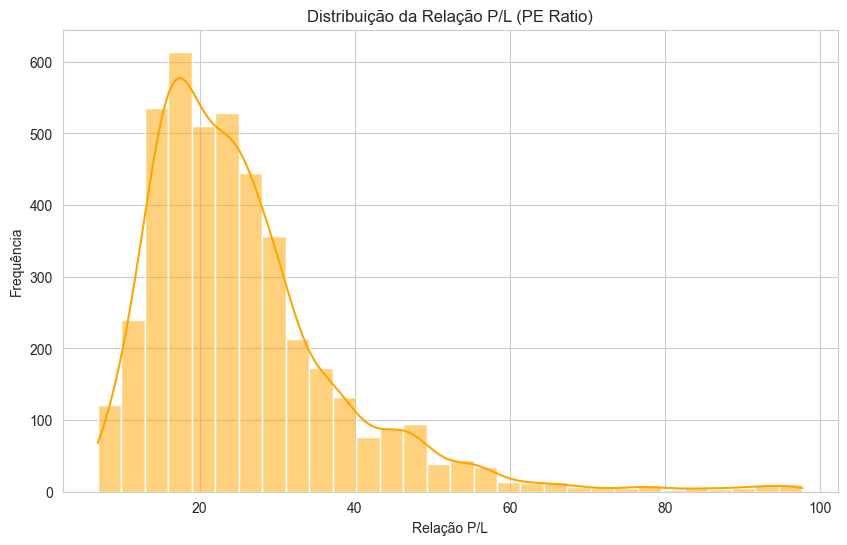

C:\Users\Usuário\AppData\Local\Temp\ipykernel_6480\1248166179.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sector', y='Dividend Yield', data=df_cap, palette='icefire')


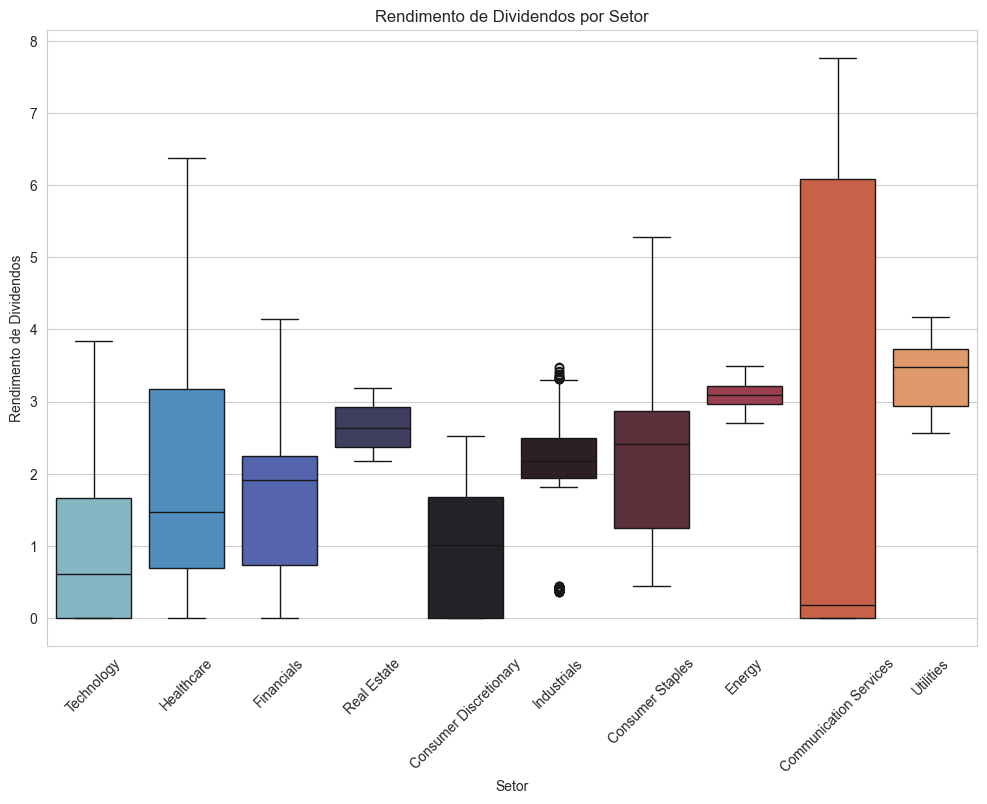

In [5]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_cap['PE Ratio'], bins=30, kde=True, color='orange')
plt.title('Distribuição da Relação P/L (PE Ratio)')
plt.xlabel('Relação P/L')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='Sector', y='Dividend Yield', data=df_cap, palette='icefire')
plt.title('Rendimento de Dividendos por Setor')
plt.xlabel('Setor')
plt.ylabel('Rendimento de Dividendos')
plt.xticks(rotation=45)
plt.show()

A maioria das empresas no conjunto de dados possui uma relação P/L entre 10 e 30.
A distribuição é assimétrica, com a maior frequência (pico) ocorrendo em torno de uma relação P/L de aproximadamente 20.
À medida que a relação P/L aumenta, a frequência das empresas diminui drasticamente, indicando que poucas empresas possuem uma relação P/L muito alta.
Há uma "cauda longa" à direita do gráfico, mostrando que, embora raros, existem alguns casos de empresas com relações P/L extremamente altas, chegando a quase 100.

O setor de Communication Services se destaca com a maior mediana e a maior faixa de rendimento de dividendos. A caixa (box) mostra uma grande dispersão de dados, e a linha mediana está em torno de 3,5%.
O setor de Utilities também apresenta um rendimento de dividendos consideravelmente alto, indicando que a maioria das empresas está na faixa de 3% a 4%.
Setores como Energy, Real Estate e Healthcare mostram uma distribuição de rendimentos moderada, com a maioria das empresas oferecendo rendimentos de dividendos entre 1% e 3%.
Os setores de Technology, Financials e Consumer Discretionary apresentam medianas mais baixas e faixas de rendimento de dividendos menores, com a maioria das empresas oferecendo rendimentos abaixo de 2%.
O setor de Consumer Discretionary é notável por ter a menor mediana de rendimento de dividendos, indicando que a maioria das empresas desse setor oferece rendimentos muito baixos ou nulos.

In [6]:
#Calcular os retornos diários
df_cap['Daily Return'] = df_cap.groupby('Ticker')['Close Price'].pct_change()

#Calcular a volatilidade anualizada para cada ticker
volatility = df_cap.groupby('Ticker')['Daily Return'].std() * (252**0.5) # 252 dias de negociação por ano

#Calcular o retorno anualizado médio
mean_return = df_cap.groupby('Ticker')['Daily Return'].mean() * 252


risk_return_df = pd.DataFrame({'Retorno Anualizado': mean_return, 'Volatilidade Anualizada': volatility})

print("Análise de Risco e Retorno:")
print(risk_return_df.head())

Análise de Risco e Retorno:
        Retorno Anualizado  Volatilidade Anualizada
Ticker                                             
AAPL              1.208497                 1.377651
ABBV             -0.031833                 0.673793
ABT               0.053520                 0.591785
ADBE              0.419346                 0.665363
ADP              -0.050679                 0.562254


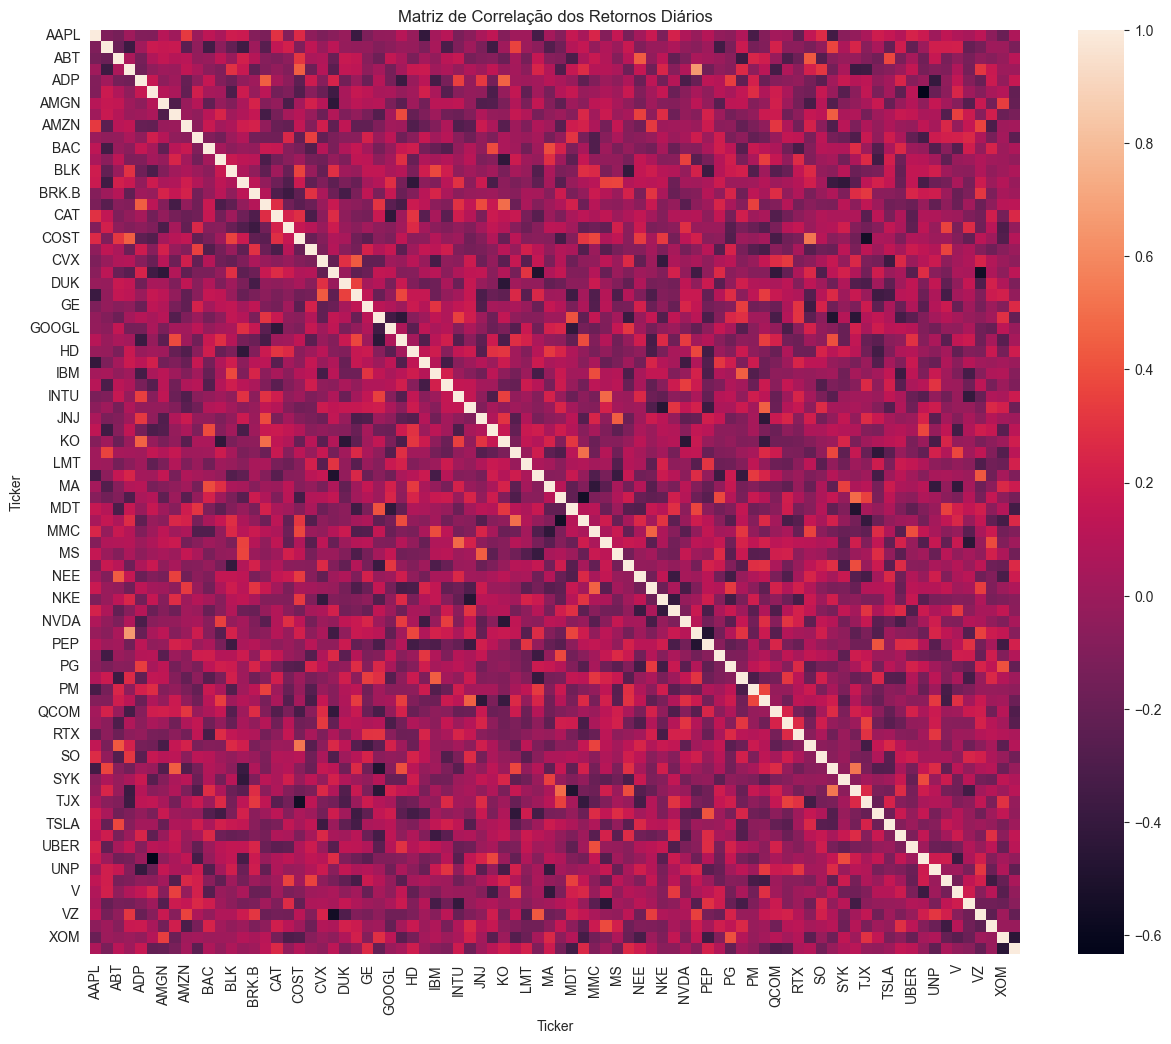

In [7]:
#Pivotar a tabela para ter tickers como colunas e datas como índice
close_prices = df_cap.pivot_table(index='Date', columns='Ticker', values='Close Price')

correlation_matrix = close_prices.pct_change().corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='rocket')
plt.title('Matriz de Correlação dos Retornos Diários')
plt.show()

A matriz de correlação mostra a relação estatística entre os retornos diários de diferentes ações. Cores mais claras (em direção ao rosa e ao laranja) indicam uma correlação positiva forte, enquanto cores mais escuras (em direção ao roxo e preto) indicam uma correlação fraca ou negativa.
Também é possível observar alguns pares com correlação mais fraca ou até negativa (pontos mais escuros), o que é valioso para estratégias de diversificação de portfólio. A inclusão de ativos com correlação baixa ou negativa pode ajudar a reduzir o risco geral do portfólio, pois eles não se movem na mesma direção.

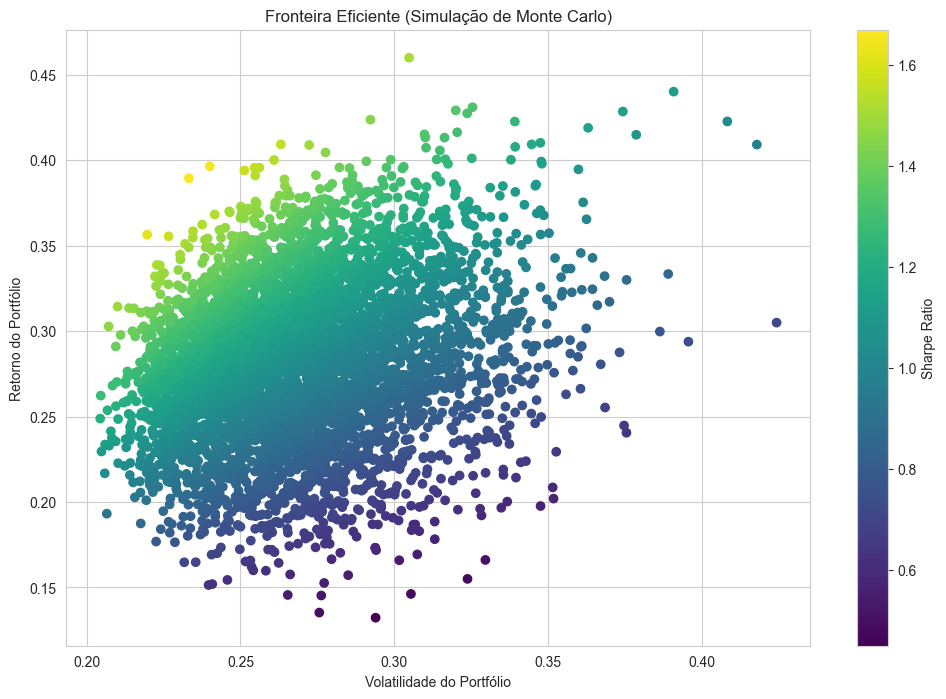

In [8]:
selected_tickers = np.random.choice(correlation_matrix.columns, 10, replace=False)
selected_returns = close_prices[selected_tickers].pct_change()
num_portfolios = 5000

portfolio_returns = []
portfolio_volatility = []
sharpe_ratios = []

for i in range(num_portfolios):
    weights = np.random.random(len(selected_tickers))
    weights /= np.sum(weights)

    annualized_return = np.sum(selected_returns.mean() * weights) * 252
    annualized_volatility = np.sqrt(np.dot(weights.T, np.dot(selected_returns.cov() * 252, weights)))

    portfolio_returns.append(annualized_return)
    portfolio_volatility.append(annualized_volatility)
    sharpe_ratios.append(annualized_return / annualized_volatility)

plt.figure(figsize=(12, 8))
plt.scatter(portfolio_volatility, portfolio_returns, c=sharpe_ratios, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.title('Fronteira Eficiente (Simulação de Monte Carlo)')
plt.xlabel('Volatilidade do Portfólio')
plt.ylabel('Retorno do Portfólio')
plt.show()

"Fronteira Eficiente (Simulação de Monte Carlo)", a principal conclusão é que o gráfico ilustra a relação entre o risco (volatilidade do portfólio) e o retorno esperado para milhares de portfólios simulados.

In [9]:
#Modelagem
aapl_df = df_cap[df_cap['Ticker'] == 'AAPL'].copy()

features = ['Open Price', 'High Price', 'Low Price', 'Volume Traded']
target = 'Close Price'

X = aapl_df[features]
y = aapl_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Modelagem Preditiva para AAPL:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Modelagem Preditiva para AAPL:
Mean Squared Error: 0.96
R-squared: 0.99


<Figure size 1500x800 with 0 Axes>

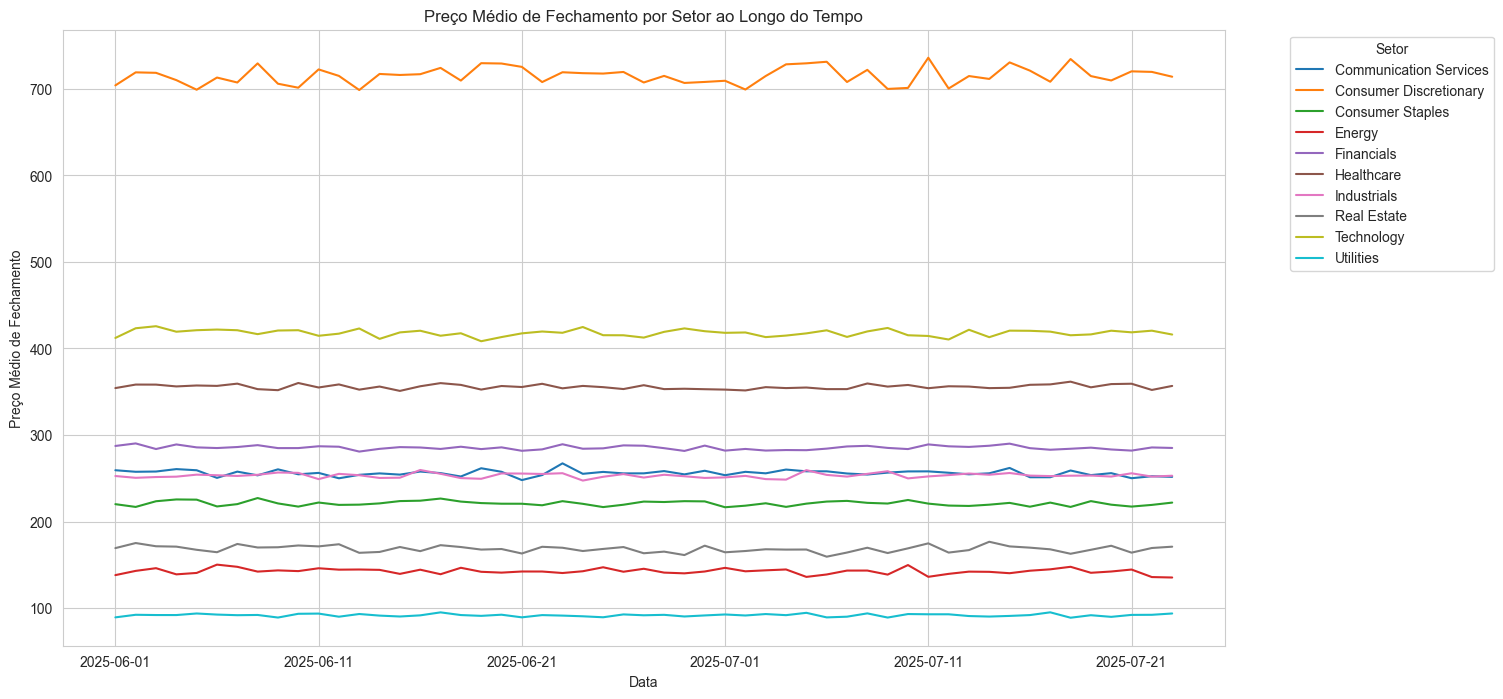

In [10]:
sector_performance = df_cap.groupby(['Date', 'Sector'])['Close Price'].mean().unstack()

plt.figure(figsize=(15, 8))
sector_performance.plot(figsize=(15, 8))
plt.title('Preço Médio de Fechamento por Setor ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Preço Médio de Fechamento')
plt.legend(title='Setor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

O setor de Consumer Discretionary manteve consistentemente os preços médios mais altos durante todo o período, variando entre cerca de 700 e 750.
O setor de Consumer Staples e Healthcare permaneceram relativamente estáveis, com o preço médio de Healthcare sendo ligeiramente superior e mais volátil do que o de Consumer Staples.
O setor de Utilities apresentou o menor preço médio de fechamento de todos os setores, mantendo-se consistentemente abaixo de 100 durante o período.
Os setores de Energy, Financials, Industrials e Real Estate apresentaram preços médios de fechamento intermediários, variando de aproximadamente 125 a 350.
Apesar de algumas flutuações, a maioria dos setores mostrou uma estabilidade geral em seus preços médios de fechamento, sem grandes picos ou quedas, ao longo do período de 1 a 21 de junho de 2025.

In [11]:
df_cap['Date'] = pd.to_datetime(df_cap['Date'])
df_cap.set_index('Date', inplace=True)


aapl_df = df_cap[df_cap['Ticker'] == 'AAPL'].copy()

aapl_df['Rolling_Mean_3'] = aapl_df['Close Price'].rolling(window=3).mean().shift(1)
aapl_df['Rolling_Mean_5'] = aapl_df['Close Price'].rolling(window=5).mean().shift(1)

aapl_df['Returns'] = aapl_df['Close Price'].pct_change()
aapl_df['Rolling_Vol_3'] = aapl_df['Returns'].rolling(window=3).std().shift(1)

aapl_df['Price_Delta'] = (aapl_df['Close Price'] - aapl_df['Open Price']) / aapl_df['Open Price']

aapl_df.dropna(inplace=True)

print("Features aprimoradas:")
print(aapl_df.head())

Features aprimoradas:
           Ticker  Open Price  Close Price  High Price  Low Price  \
Date                                                                
2025-06-06   AAPL      200.95       195.53      203.35     192.85   
2025-06-07   AAPL      216.21       210.88      219.20     210.03   
2025-06-08   AAPL      207.88       213.54      215.04     206.62   
2025-06-09   AAPL      219.80       212.32      220.42     211.70   
2025-06-10   AAPL      194.39       189.83      195.30     187.27   

            Volume Traded    Market Cap  PE Ratio  Dividend Yield   EPS  ...  \
Date                                                                     ...   
2025-06-06       64831615  3.052176e+12     27.23            0.47  7.18  ...   
2025-06-07       83351924  3.291785e+12     28.18            0.54  7.48  ...   
2025-06-08       39916529  3.333307e+12     24.67            0.53  8.66  ...   
2025-06-09       80271583  3.314263e+12     31.12            0.52  6.82  ...   
2025-06-10    

In [12]:
features = ['Open Price', 'High Price', 'Low Price', 'Volume Traded',
            'Rolling_Mean_3', 'Rolling_Mean_5', 'Rolling_Vol_3']
target = 'Close Price'

X = aapl_df[features]
y = aapl_df[target]

split_index = int(len(aapl_df) * 0.8)
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Modelagem Preditiva Aprimorada para AAPL:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Modelagem Preditiva Aprimorada para AAPL:
Mean Squared Error: 1.07
R-squared: 0.99


In [15]:
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.efficient_frontier import EfficientFrontier

In [17]:
close_prices = df_cap.pivot_table(index='Date', columns='Ticker', values='Close Price')

mu = expected_returns.mean_historical_return(close_prices)
S = risk_models.sample_cov(close_prices)

ef = EfficientFrontier(mu, S)

weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print("Pesos do Portfólio com Máximo Sharpe:")
print(cleaned_weights)

performance = ef.portfolio_performance(verbose=True)

Pesos do Portfólio com Máximo Sharpe:
OrderedDict([('AAPL', 0.0054), ('ABBV', 0.0), ('ABT', 0.0), ('ADBE', 0.0), ('ADP', 0.01176), ('AMD', 0.0), ('AMGN', 0.03327), ('AMT', 0.0), ('AMZN', 0.0), ('AVGO', 0.0133), ('BAC', 0.00235), ('BKNG', 0.02783), ('BLK', 0.00588), ('BMY', 0.0294), ('BRK.B', 0.0), ('C', 0.0061), ('CAT', 0.0), ('CB', 0.0), ('COST', 0.06239), ('CRM', 0.0), ('CVX', 0.01084), ('DIS', 0.0107), ('DUK', 0.05972), ('ELV', 0.0088), ('GE', 0.0), ('GILD', 0.03688), ('GOOGL', 0.0485), ('GS', 0.0), ('HD', 0.06049), ('HON', 0.00671), ('IBM', 0.03032), ('INTC', 0.0), ('INTU', 0.00731), ('ISRG', 0.0), ('JNJ', 0.0), ('JPM', 0.0), ('KO', 0.01131), ('LLY', 0.02977), ('LMT', 0.0), ('LOW', 0.01636), ('MA', 0.02981), ('MDLZ', 0.0), ('MDT', 0.0), ('META', 0.01501), ('MMC', 0.0), ('MRK', 0.0), ('MS', 0.01107), ('MSFT', 0.0), ('NEE', 0.0), ('NFLX', 0.0), ('NKE', 0.01132), ('NOW', 0.0479), ('NVDA', 0.0), ('ORCL', 0.0), ('PEP', 0.0626), ('PFE', 0.0), ('PG', 0.0), ('PLD', 0.0), ('PM', 0.02436), (

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\pypfopt\risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(


In [18]:
daily_returns = close_prices.pct_change().dropna()

weights = np.array([1/len(daily_returns.columns)] * len(daily_returns.columns))
portfolio_returns = daily_returns.dot(weights)

confidence_level = 0.99
VaR = portfolio_returns.quantile(1 - confidence_level)

print(f"Value at Risk (VaR) do Portfólio (99% de Confiança): {VaR:.4f}")

Value at Risk (VaR) do Portfólio (99% de Confiança): -0.0063


In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

nvda_df = df_cap[df_cap['Ticker'] == 'NVDA'].copy()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03, row_heights=[0.7, 0.3])

fig.add_trace(go.Candlestick(x=nvda_df.index,
                             open=nvda_df['Open Price'],
                             high=nvda_df['High Price'],
                             low=nvda_df['Low Price'],
                             close=nvda_df['Close Price'],
                             name='Preço da Ação'),
              row=1, col=1)

fig.add_trace(go.Bar(x=nvda_df.index, y=nvda_df['Volume Traded'], name='Volume'),
              row=2, col=1)

fig.update_layout(title_text='Análise Interativa de Ações da NVDA',
                  xaxis_rangeslider_visible=False,
                  template='plotly_dark')
fig.show()

Ao combinar ações de alta volatilidade (como NVDA ou TSLA) com outras mais estáveis (como as do setor de Serviços Públicos), o investidor pode potencialmente mitigar o risco geral do portfólio sem sacrificar o potencial de retorno.

# Conclusão
Considerando a volatilidade variável entre os setores (com Tecnologia e Energia apresentando maior volatilidade, e Serviços Públicos a menor) e as diferentes relações de risco-retorno entre as ações, uma estratégia eficaz seria construir um portfólio diversificado que combine ativos com baixa correlação.
A otimização de portfólio, como a realizada com a simulação de Monte Carlo, permite encontrar a combinação ideal de pesos de ativos que maximiza o retorno para um determinado nível de risco (Sharpe Ratio), ou minimiza o risco para um retorno desejado. Ao combinar ações de alta volatilidade (como NVDA ou TSLA) com outras mais estáveis (como as do setor de Serviços Públicos), o investidor pode potencialmente mitigar o risco geral do portfólio sem sacrificar o potencial de retorno.
O conjunto de dados, embora com um período limitado de 21 dias úteis (1 a 21 de junho de 2025), oferece uma visão detalhada e representativa do mercado de ações, cobrindo mais de 500 empresas. As análises de risco e retorno mostraram a variabilidade entre diferentes ações, com a otimização de portfólio destacando a importância da diversificação para maximizar o retorno em relação ao risco.

# **Nathália Sorg**